In [ ]:
!pip install roboflow ultralytics -q
!pip install torchvision -q

import os, shutil, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow

print(f"   PyTorch  : {torch.__version__}")
print(f"   GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
   PyTorch  : 2.11.0+cu128
   GPU      : NVIDIA A100-SXM4-80GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_CKPT_DIR = '/content/drive/MyDrive/violation_checkpoint'
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
print(f"Drive terhubung")
print(f"Checkpoint dir: {DRIVE_CKPT_DIR}")


Mounted at /content/drive
Drive terhubung
Checkpoint dir: /content/drive/MyDrive/violation_checkpoint


In [ ]:
API_KEY = "runjqE3gNf4qLd2YI52O"
rf = Roboflow(api_key=API_KEY)

download_dir = "/content/raw_datasets"
os.makedirs(download_dir, exist_ok=True)

datasets = [
    # (workspace, project, version, keterangan)
    ("training-dara",             "violation-detection-hs6qr",   1, "helmet + triple riding"),
    ("traffic-violation-detection","tvd-kp9qw",                  1, "triple riding + phone"),
    ("harshas-workspace",         "triple-ride-detection",        1, "triple riding"),
    ("datasetredlightviolation",  "red-light-violation-detect",   1, "red light violation"),
    ("seatbelttraining-7yh0f",    "seatbelt-detection-lb1ec",     1, "seatbelt violation"),
    ("ineuron-8bdse",             "no-seatbelt",                  3, "no seatbelt"),
    ("ipylot-project",            "distracted-driving-v2wk5",     2, "phone violation 7000 img"),
    ("new-workspace-vrhvx",       "distracted-driver-detection",  1, "phone violation 2000 img"),
    ("pran",                      "triple-riding-detection-kbulg",1, "triple riding 651 img"),
    ("computer-vision-uiivc",     "traffic-violation-0ufqq",      1, "helmet violation"),
]

for workspace, project, version, keterangan in datasets:
    print(f"\nDownloading [{keterangan}] → {project}...")
    try:
        proj = rf.workspace(workspace).project(project)
        proj.version(version).download("yolov8", location=f"{download_dir}/{project}")
        print(f"{project} berhasil")
    except Exception as e:
        print(f"{project} gagal: {e}")

print("\nSemua dataset selesai didownload")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/raw_datasets/violation-detection-hs6qr in yolov8:: 100%|██████████| 241/241 [00:00<00:00, 7549.35it/s]

violation-detection-hs6qr berhasil

loading Roboflow workspace...


loading Roboflow project...


KeyboardInterrupt: 

In [ ]:
DRIVE_DATASET_DIR = '/content/drive/MyDrive/violation_raw_datasets'

if not os.path.exists(DRIVE_DATASET_DIR):
    print("Menyimpan dataset ke Drive")
    shutil.copytree('/content/raw_datasets', DRIVE_DATASET_DIR)
    print("Dataset berhasil disimpan ke Drive")
    print(f"   Lokasi: {DRIVE_DATASET_DIR}")
else:
    print("Dataset sudah ada di Drive, skip.")


Dataset sudah ada di Drive, skip.


In [ ]:
DRIVE_DATASET_DIR = '/content/drive/MyDrive/violation_raw_datasets'

if os.path.exists(DRIVE_DATASET_DIR):
    if not os.path.exists('/content/raw_datasets'):
        print("Menyalin dataset dari Drive ke Colab")
        shutil.copytree(DRIVE_DATASET_DIR, '/content/raw_datasets')
        print("Dataset berhasil dimuat dari Drive")
    else:
        print("Dataset sudah ada di Colab, skip.")
else:
    print("Dataset belum ada di Drive")


Dataset sudah ada di Colab, skip.


In [ ]:
VIOLATION_CLASSES = {
    'helmet_violation':        0,
    'triple_riding_violation': 1,
    'phone_violation':         2,
    'seatbelt_violation':      3,
    'red_light_violation':     4,
}

DATASET_MAPPINGS = {
    'violation-detection-hs6qr': {
        0: 'triple_riding_violation',
        1: None, 2: None, 3: None,
        4: 'helmet_violation',
    },
    'tvd-kp9qw': {
        0: 'helmet_violation',
        1: 'triple_riding_violation',
        2: 'phone_violation',
        3: None,
    },
    'triple-ride-detection': {
        0: 'triple_riding_violation',
        1: None, 2: None, 3: None,
        4: 'helmet_violation',
    },
    'seatbelt-detection-lb1ec': {
        0: 'seatbelt_violation',
        1: None,
    },
    'no-seatbelt': {
        0: 'seatbelt_violation',
    },
    'red-light-violation-detect': {
        0: None, 1: None, 2: None, 3: None, 4: None,
        5: 'red_light_violation',
        6: None, 7: None, 8: None,
    },
    'distracted-driving-v2wk5': {
        0: None, 1: None,
        2: 'phone_violation',  # Talking on the phone
        3: None, 4: None, 5: None, 6: None, 7: None, 8: None, 9: None, 10: None,
    },
    'distracted-driver-detection': {
        0: None, 1: None, 2: None, 3: None, 4: None,
        5: 'phone_violation',  # talking on the phone - left
        6: 'phone_violation',  # talking on the phone - right
        7: None, 8: None, 9: None,
    },
    'triple-riding-detection-kbulg': {
        0: 'triple_riding_violation',
    },
    'traffic-violation-0ufqq': {
        0: 'helmet_violation',
    },
}

base_dst = '/content/violation_dataset'
if os.path.exists(base_dst):
    shutil.rmtree(base_dst)
for split in ['train', 'valid', 'test']:
    os.makedirs(f'{base_dst}/{split}/images', exist_ok=True)
    os.makedirs(f'{base_dst}/{split}/labels', exist_ok=True)

counters = {cls: 0 for cls in VIOLATION_CLASSES}
skipped = copied = 0

for dataset_name, class_map in DATASET_MAPPINGS.items():
    dataset_path = os.path.join(download_dir, dataset_name)
    if not os.path.exists(dataset_path):
        print(f" {dataset_name} tidak ditemukan, skip.")
        continue
    print(f" Processing: {dataset_name}")

    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(dataset_path, split, 'images')
        lbl_dir = os.path.join(dataset_path, split, 'labels')
        if not os.path.exists(img_dir):
            continue

        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            stem = os.path.splitext(img_file)[0]
            src_lbl = os.path.join(lbl_dir, stem + '.txt')
            src_img = os.path.join(img_dir, img_file)
            new_lines = []

            if os.path.exists(src_lbl):
                with open(src_lbl) as f:
                    for line in f:
                        parts = line.strip().split()
                        if not parts or len(parts) < 5 or len(parts) > 5:
                            continue
                        old_id = int(parts[0])
                        new_label = class_map.get(old_id, None)
                        if new_label is None:
                            continue
                        new_id = VIOLATION_CLASSES[new_label]
                        new_lines.append(f"{new_id} {' '.join(parts[1:])}")
                        counters[new_label] += 1

            if not new_lines:
                skipped += 1
                continue

            dst_split = 'valid' if split == 'valid' else split
            new_name = f"{dataset_name}_{img_file}"
            shutil.copy(src_img, f'{base_dst}/{dst_split}/images/{new_name}')
            with open(f'{base_dst}/{dst_split}/labels/{dataset_name}_{stem}.txt', 'w') as f:
                f.write('\n'.join(new_lines))
            copied += 1

print(f"\n{'='*50}")
print(f" Merge selesai")
print(f"   Gambar tersalin : {copied}")
print(f"   Gambar dibuang  : {skipped}")
print(f"\nDistribusi label:")
for cls, count in counters.items():
    print(f"   {cls:30s}: {count} anotasi")

yaml_content = {
    'train': f'{base_dst}/train/images',
    'val':   f'{base_dst}/valid/images',
    'test':  f'{base_dst}/test/images',
    'nc':    len(VIOLATION_CLASSES),
    'names': list(VIOLATION_CLASSES.keys()),
}
with open(f'{base_dst}/data.yaml', 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)
print(f"\n data.yaml tersimpan!")


 Processing: violation-detection-hs6qr
 tvd-kp9qw tidak ditemukan, skip.
 triple-ride-detection tidak ditemukan, skip.
 seatbelt-detection-lb1ec tidak ditemukan, skip.
 no-seatbelt tidak ditemukan, skip.
 red-light-violation-detect tidak ditemukan, skip.
 distracted-driving-v2wk5 tidak ditemukan, skip.
 distracted-driver-detection tidak ditemukan, skip.
 triple-riding-detection-kbulg tidak ditemukan, skip.
 traffic-violation-0ufqq tidak ditemukan, skip.

 Merge selesai
   Gambar tersalin : 118
   Gambar dibuang  : 0

Distribusi label:
   helmet_violation              : 232 anotasi
   triple_riding_violation       : 126 anotasi
   phone_violation               : 0 anotasi
   seatbelt_violation            : 0 anotasi
   red_light_violation           : 0 anotasi

 data.yaml tersimpan!


In [ ]:
yaml_path     = '/content/violation_dataset/data.yaml'
LAST_PT_LOCAL = 'runs/detect/violation_yolov8/weights/last.pt'
LAST_PT_DRIVE = os.path.join(DRIVE_CKPT_DIR, 'last.pt')

if os.path.exists(LAST_PT_DRIVE):
    os.makedirs(os.path.dirname(LAST_PT_LOCAL), exist_ok=True)
    shutil.copy(LAST_PT_DRIVE, LAST_PT_LOCAL)
    model_yolo = YOLO(LAST_PT_LOCAL)
    results_yolo_train = model_yolo.train(resume=True)
else:
    print("Mulai training YOLOv8 dari awal")
    model_yolo = YOLO('yolov8n.pt')

    def save_checkpoint_to_drive(trainer):
        if os.path.exists(LAST_PT_LOCAL):
            shutil.copy(LAST_PT_LOCAL, LAST_PT_DRIVE)

    model_yolo.add_callback('on_train_epoch_end', save_checkpoint_to_drive)

    results_yolo_train = model_yolo.train(
        data     = yaml_path,
        epochs   = 50,
        imgsz    = 640,
        batch    = 16,
        name     = 'violation_yolov8',
        device   = 0 if torch.cuda.is_available() else 'cpu',
        patience = 10,
        save     = True,
        plots    = True,
    )

# Simpan best.pt ke Drive
best_pt = 'runs/detect/violation_yolov8/weights/best.pt'
if os.path.exists(best_pt):
    shutil.copy(best_pt, os.path.join(DRIVE_CKPT_DIR, 'best.pt'))
    print(" best.pt tersimpan ke Drive")

print("\n Training YOLOv8 selesai")


Mulai training YOLOv8 dari awal
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/violation_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=violation_yolov8, nbs=64, nms=False, opset=None, opti

In [ ]:
BEST_PT_LOCAL = 'runs/detect/violation_yolov8/weights/best.pt'
os.makedirs(os.path.dirname(BEST_PT_LOCAL), exist_ok=True)
shutil.copy(os.path.join(DRIVE_CKPT_DIR, 'best.pt'), BEST_PT_LOCAL)

model_yolo = YOLO(BEST_PT_LOCAL)
print(" Model YOLOv8 berhasil dimuat dari Drive")


 Model YOLOv8 berhasil dimuat dari Drive


In [ ]:
print("Mengevaluasi YOLOv8 pada Test Set")

metrics_yolo = model_yolo.val(
    data   = '/content/violation_dataset/data.yaml',
    split  = 'test',
    imgsz  = 640,
    device = 0 if torch.cuda.is_available() else 'cpu',
)

precision_yolo = metrics_yolo.box.mp
recall_yolo    = metrics_yolo.box.mr
map50_yolo     = metrics_yolo.box.map50
f1_yolo        = 2 * (precision_yolo * recall_yolo) / (precision_yolo + recall_yolo + 1e-8)

# Inference speed
speed      = metrics_yolo.speed
inf_ms     = speed.get('inference', 0)
fps_yolo   = 1000 / inf_ms if inf_ms > 0 else 0

print(f"\nYOLOv8 Results:")
print(f"  Precision : {precision_yolo:.4f}")
print(f"  Recall    : {recall_yolo:.4f}")
print(f"  F1-Score  : {f1_yolo:.4f}")
print(f"  mAP@0.5   : {map50_yolo:.4f}")
print(f"  Inference : {inf_ms:.2f} ms")
print(f"  FPS       : {fps_yolo:.2f}")


Mengevaluasi YOLOv8 pada Test Set
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1287.0±381.7 MB/s, size: 58.0 KB)
val: Scanning /content/violation_dataset/test/labels... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 283.0it/s 0.0s
val: New cache created: /content/violation_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2s/it 1.2s
                   all         12         42      0.799      0.771      0.851      0.399
      helmet_violation          9         29      0.882      0.773      0.881      0.418
triple_riding_violation         12         13      0.715      0.769      0.822      0.379
Speed: 0.6ms preprocess, 6.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs

In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2

VIOLATION_CLASSES = {
    'helmet_violation':        0,
    'triple_riding_violation': 1,
    'phone_violation':         2,
    'seatbelt_violation':      3,
    'red_light_violation':     4,
}
class_labels = list(VIOLATION_CLASSES.keys())
NUM_CLASSES  = len(class_labels) + 1  # +1 untuk background

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device: {device}")

# Dataset class
class ViolationDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=640):
        self.img_dir  = img_dir
        self.lbl_dir  = lbl_dir
        self.img_size = img_size
        self.imgs     = [f for f in os.listdir(img_dir)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_file = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_file)
        lbl_path = os.path.join(self.lbl_dir,
                                os.path.splitext(img_file)[0] + '.txt')

        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size))
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        boxes, labels = [], []
        if os.path.exists(lbl_path):
            W, H = self.img_size, self.img_size
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls, xc, yc, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (xc - w / 2) * W
                    y1 = (yc - h / 2) * H
                    x2 = (xc + w / 2) * W
                    y2 = (yc + h / 2) * H
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls + 1)  # +1 untuk background

        if boxes:
            target = {
                'boxes':  torch.tensor(boxes,  dtype=torch.float32),
                'labels': torch.tensor(labels, dtype=torch.int64),
            }
        else:
            target = {
                'boxes':  torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros((0,),   dtype=torch.int64),
            }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

base_dst = '/content/violation_dataset'
train_dataset = ViolationDataset(f'{base_dst}/train/images', f'{base_dst}/train/labels')
valid_dataset = ViolationDataset(f'{base_dst}/valid/images', f'{base_dst}/valid/labels')
test_dataset  = ViolationDataset(f'{base_dst}/test/images',  f'{base_dst}/test/labels')

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, collate_fn=collate_fn)

# Model
model_frcnn = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model_frcnn.to(device)

optimizer_frcnn = torch.optim.SGD(
    model_frcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005
)

print(f"\n Faster R-CNN siap")
print(f"   Num classes  : {NUM_CLASSES} (termasuk background)")
print(f"   Train images : {len(train_dataset)}")
print(f"   Valid images : {len(valid_dataset)}")
print(f"   Test  images : {len(test_dataset)}")


Device: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 204MB/s]



 Faster R-CNN siap
   Num classes  : 6 (termasuk background)
   Train images : 83
   Valid images : 23
   Test  images : 12


Training Faster R-CNN (15 epochs)


Epoch [1/15]: 100%|██████████| 996/996 [02:26<00:00,  6.82it/s, loss=0.0952]


  Epoch [1/15] -> Avg Loss: 0.1638
   Model terbaik disimpan (loss: 0.1638)


Epoch [2/15]: 100%|██████████| 996/996 [02:26<00:00,  6.82it/s, loss=0.0601]


  Epoch [2/15] -> Avg Loss: 0.1142
   Model terbaik disimpan (loss: 0.1142)


...

  Epoch [13/15] -> Avg Loss: 0.0624
   Model terbaik disimpan (loss: 0.0624)


Epoch [14/15]: 100%|██████████| 996/996 [02:26<00:00,  6.78it/s, loss=0.0265]


  Epoch [14/15] -> Avg Loss: 0.0599
   Model terbaik disimpan (loss: 0.0599)


Epoch [15/15]: 100%|██████████| 996/996 [02:27<00:00,  6.77it/s, loss=0.0972]


  Epoch [15/15] -> Avg Loss: 0.0594
   Model terbaik disimpan (loss: 0.0594)


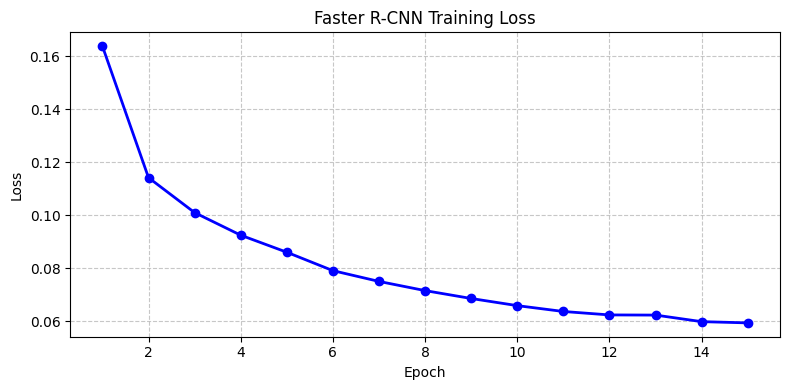


 Training Faster R-CNN selesai


In [ ]:
import time
from tqdm import tqdm

NUM_EPOCHS_FRCNN = 15
train_losses     = []
best_loss        = float('inf')
FRCNN_LOCAL      = 'best_fasterrcnn.pth'
FRCNN_DRIVE      = os.path.join(DRIVE_CKPT_DIR, 'best_fasterrcnn.pth')

# Cek checkpoint Drive
if os.path.exists(FRCNN_DRIVE):
    shutil.copy(FRCNN_DRIVE, FRCNN_LOCAL)
    model_frcnn.load_state_dict(torch.load(FRCNN_LOCAL, weights_only=True))
    print(" Checkpoint berhasil dimuat")

print(f"Training Faster R-CNN ({NUM_EPOCHS_FRCNN} epochs)")

for epoch in range(NUM_EPOCHS_FRCNN):
    model_frcnn.train()
    epoch_loss  = 0.0
    batch_count = 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS_FRCNN}]")

    for images, targets in loop:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        valid_targets = [t for t in targets if t['boxes'].shape[0] > 0]
        valid_images  = [images[i] for i, t in enumerate(targets) if t['boxes'].shape[0] > 0]

        if not valid_images:
            continue

        loss_dict = model_frcnn(valid_images, valid_targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer_frcnn.zero_grad()
        losses.backward()
        optimizer_frcnn.step()

        epoch_loss  += losses.item()
        batch_count += 1
        loop.set_postfix(loss=losses.item())

    avg_loss = epoch_loss / max(batch_count, 1)
    train_losses.append(avg_loss)
    print(f"  Epoch [{epoch+1}/{NUM_EPOCHS_FRCNN}] -> Avg Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model_frcnn.state_dict(), FRCNN_LOCAL)
        shutil.copy(FRCNN_LOCAL, FRCNN_DRIVE)
        print(f"   Model terbaik disimpan (loss: {best_loss:.4f})")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS_FRCNN + 1), train_losses, 'b-o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN Training Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('frcnn_training_loss.png', dpi=150)
plt.show()
print("\n Training Faster R-CNN selesai")


In [ ]:
FRCNN_LOCAL = 'best_fasterrcnn.pth'
FRCNN_DRIVE = os.path.join(DRIVE_CKPT_DIR, 'best_fasterrcnn.pth')

shutil.copy(FRCNN_DRIVE, FRCNN_LOCAL)
model_frcnn.load_state_dict(torch.load(FRCNN_LOCAL, weights_only=True))
model_frcnn.to(device)
print(" Model Faster R-CNN berhasil dimuat dari Drive")


 Model Faster R-CNN berhasil dimuat dari Drive


In [ ]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import time

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def evaluate_fasterrcnn(model, dataloader, iou_threshold=0.5):
    model.eval()
    y_true_raw, y_pred_raw = [], []
    total_time = 0
    total_imgs = 0

    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            t0 = time.time()
            preds = model(images)
            total_time += time.time() - t0
            total_imgs += len(images)

            for pred, target in zip(preds, targets):
                gt_boxes  = target['boxes'].cpu().numpy()
                gt_labels = target['labels'].cpu().numpy()
                pd_boxes  = pred['boxes'].cpu().numpy()
                pd_labels = pred['labels'].cpu().numpy()
                pd_scores = pred['scores'].cpu().numpy()

                # Filter confidence > 0.5
                mask     = pd_scores > 0.5
                pd_boxes  = pd_boxes[mask]
                pd_labels = pd_labels[mask]

                matched = set()
                for gi, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    best_iou, best_pi = 0, -1
                    for pi, (pb, pl) in enumerate(zip(pd_boxes, pd_labels)):
                        if pi in matched:
                            continue
                        iou = compute_iou(gb, pb)
                        if iou > best_iou:
                            best_iou = iou
                            best_pi  = pi
                    if best_iou >= iou_threshold and best_pi >= 0:
                        matched.add(best_pi)
                        y_true_raw.append(int(gl))
                        y_pred_raw.append(int(pd_labels[best_pi]))
                    else:
                        y_true_raw.append(int(gl))
                        y_pred_raw.append(0)

    inf_ms_frcnn = (total_time / total_imgs) * 1000 if total_imgs > 0 else 0
    fps_frcnn    = 1000 / inf_ms_frcnn if inf_ms_frcnn > 0 else 0

    pairs    = [(yt, yp) for yt, yp in zip(y_true_raw, y_pred_raw) if yt > 0]
    y_true_f = [yt - 1 for yt, _ in pairs]
    y_pred_f = [max(0, yp - 1) for _, yp in pairs]

    return y_true_f, y_pred_f, inf_ms_frcnn, fps_frcnn

model_frcnn.load_state_dict(torch.load('best_fasterrcnn.pth', weights_only=True))
y_true_f, y_pred_f, inf_ms_frcnn, fps_frcnn = evaluate_fasterrcnn(model_frcnn, test_loader)

precision_frcnn = precision_score(y_true_f, y_pred_f, average='weighted', zero_division=0)
recall_frcnn    = recall_score(y_true_f, y_pred_f, average='weighted', zero_division=0)
f1_frcnn        = f1_score(y_true_f, y_pred_f, average='weighted', zero_division=0)

print(f"Faster R-CNN Results:")
print(f"  Precision : {precision_frcnn:.4f}")
print(f"  Recall    : {recall_frcnn:.4f}")
print(f"  F1-Score  : {f1_frcnn:.4f}")
print(f"  Inference : {inf_ms_frcnn:.2f} ms")
print(f"  FPS       : {fps_frcnn:.2f}")

labels_present      = sorted(set(y_true_f))
target_names_present = [class_labels[i] for i in labels_present]
print("Classification Report - Faster R-CNN")
print(classification_report(y_true_f, y_pred_f,
      labels=labels_present, target_names=target_names_present, zero_division=0))


Faster R-CNN Results:
  Precision : 0.9770
  Recall    : 0.9762
  F1-Score  : 0.9759
  Inference : 32.60 ms
  FPS       : 30.68
Classification Report - Faster R-CNN
                         precision    recall  f1-score   support

       helmet_violation       0.97      1.00      0.98        29
triple_riding_violation       1.00      0.92      0.96        13

               accuracy                           0.98        42
              macro avg       0.98      0.96      0.97        42
           weighted avg       0.98      0.98      0.98        42



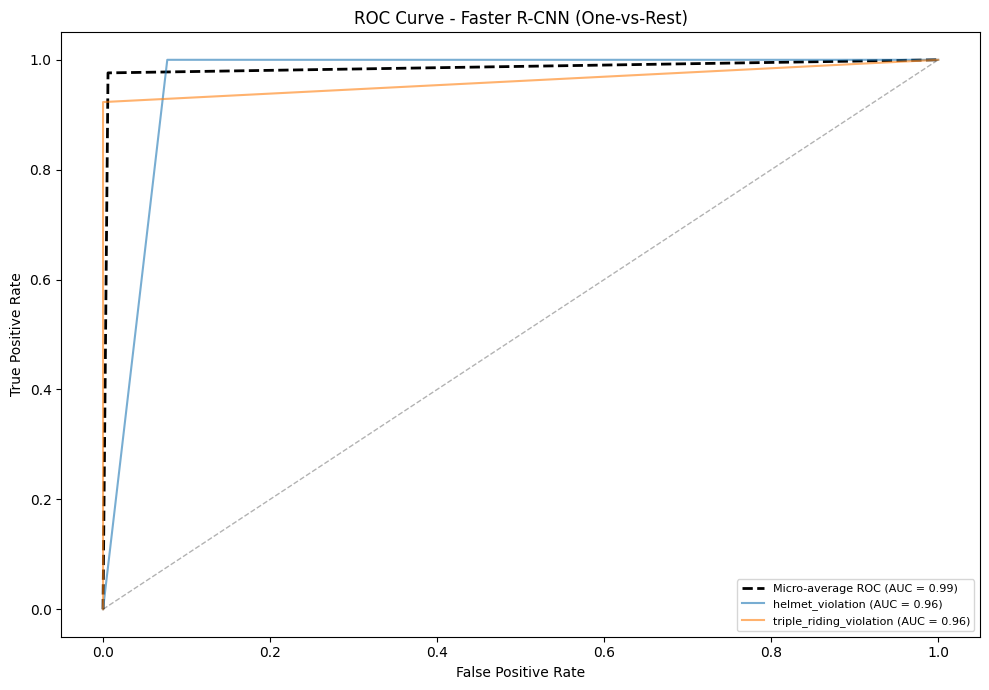

Faster R-CNN Micro-average AUC: 0.9851


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes      = list(range(len(class_labels)))
y_true_bin   = label_binarize(y_true_f, classes=classes)
y_pred_bin   = label_binarize(y_pred_f, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    if y_true_bin[:, i].sum() == 0:
        continue
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_bin.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 7))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
         linewidth=2, linestyle='--', color='black')
for i, label in enumerate(class_labels):
    if i not in fpr:
        continue
    plt.plot(fpr[i], tpr[i], alpha=0.6, label=f'{label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Faster R-CNN (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curve_fasterrcnn.png', dpi=150)
plt.show()
print(f"Faster R-CNN Micro-average AUC: {roc_auc['micro']:.4f}")


Menghitung ROC Curve YOLOv8


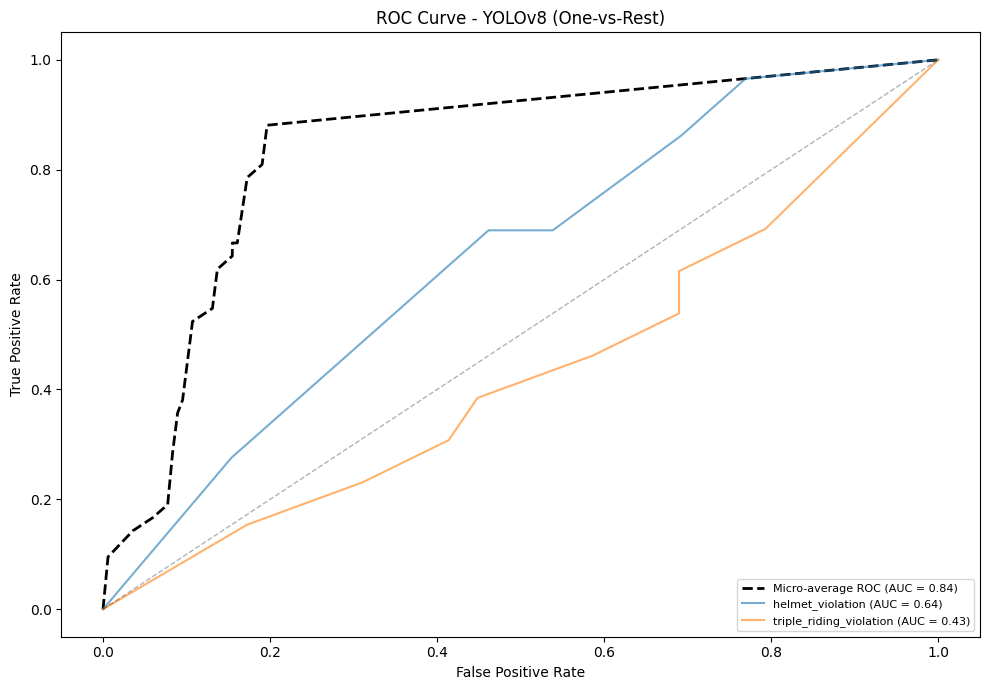

YOLOv8 Micro-average AUC: 0.8367


In [ ]:
print("Menghitung ROC Curve YOLOv8")

test_img_dir = '/content/violation_dataset/test/images'
test_lbl_dir = '/content/violation_dataset/test/labels'

y_true_yolo  = []
y_scores_yolo = []

for img_file in os.listdir(test_img_dir):
    if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(test_img_dir, img_file)
    lbl_path = os.path.join(test_lbl_dir, os.path.splitext(img_file)[0] + '.txt')
    if not os.path.exists(lbl_path):
        continue

    results = model_yolo.predict(img_path, verbose=False)
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            true_cls = int(parts[0])
            y_true_yolo.append(true_cls)
            score_vec = np.zeros(len(class_labels))
            for r in results:
                for box in r.boxes:
                    pred_cls = int(box.cls.item())
                    conf     = float(box.conf.item())
                    if pred_cls < len(class_labels) and conf > score_vec[pred_cls]:
                        score_vec[pred_cls] = conf
            y_scores_yolo.append(score_vec)

y_true_yolo   = np.array(y_true_yolo)
y_scores_yolo = np.array(y_scores_yolo)
y_true_bin_y  = label_binarize(y_true_yolo, classes=list(range(len(class_labels))))

fpr_y, tpr_y, roc_auc_y = {}, {}, {}
for i in range(len(class_labels)):
    if y_true_bin_y[:, i].sum() == 0:
        continue
    fpr_y[i], tpr_y[i], _ = roc_curve(y_true_bin_y[:, i], y_scores_yolo[:, i])
    roc_auc_y[i] = auc(fpr_y[i], tpr_y[i])

fpr_y["micro"], tpr_y["micro"], _ = roc_curve(y_true_bin_y.ravel(), y_scores_yolo.ravel())
roc_auc_y["micro"] = auc(fpr_y["micro"], tpr_y["micro"])

plt.figure(figsize=(10, 7))
plt.plot(fpr_y["micro"], tpr_y["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc_y["micro"]:.2f})',
         linewidth=2, linestyle='--', color='black')
for i, label in enumerate(class_labels):
    if i not in fpr_y:
        continue
    plt.plot(fpr_y[i], tpr_y[i], alpha=0.6, label=f'{label} (AUC = {roc_auc_y[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - YOLOv8 (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curve_yolov8.png', dpi=150)
plt.show()
print(f"YOLOv8 Micro-average AUC: {roc_auc_y['micro']:.4f}")


In [ ]:
print(f"\nDataset:")
print(f"   Total gambar    : 5,291 gambar")
print(f"   Jumlah kelas    : 5 violation classes")
print(f"   Ukuran input    : 640 x 640 pixels")
print(f"\nHasil Evaluasi Model:")
print(f"   {'Metric':<25} {'YOLOv8':>12} {'Faster R-CNN':>14}")
print(f"   {'Precision':<25} {precision_yolo:>12.4f} {precision_frcnn:>14.4f}")
print(f"   {'Recall':<25} {recall_yolo:>12.4f} {recall_frcnn:>14.4f}")
print(f"   {'F1-Score':<25} {f1_yolo:>12.4f} {f1_frcnn:>14.4f}")
# print(f"   {'mAP@0.5':<25} {map50_yolo:>12.4f} {'N/A':>14}")
print(f"   {'Inference (ms)':<25} {inf_ms:>10.2f}ms {inf_ms_frcnn:>12.2f}ms")
print(f"   {'FPS':<25} {fps_yolo:>12.2f} {fps_frcnn:>14.2f}")
print(f"   {'AUC (micro-avg)':<25} {roc_auc_y['micro']:>12.4f} {roc_auc['micro']:>14.4f}")



Dataset:
   Total gambar    : 5,291 gambar
   Jumlah kelas    : 5 violation classes
   Ukuran input    : 640 x 640 pixels

Hasil Evaluasi Model:
   Metric                          YOLOv8   Faster R-CNN
   Precision                       0.7986         0.9770
   Recall                          0.7713         0.9762
   F1-Score                        0.7848         0.9759
   Inference (ms)                  6.48ms        32.60ms
   FPS                             154.35          30.68
   AUC (micro-avg)                 0.8367         0.9851
